In [25]:
import numpy as np
import pandas as pd

In [26]:

# Steps

# 0. Preprocess + EDA + Feature Selection   (handle missing values, outliers, categorical variables, visualize data and select important features)
# 1. Extract input and output cols          (define X and y means input and output variables)
# 2. Scale the values                       (normalize or standardize the features ie. bween 0 and 1 or mean=0 and std=1)
# 3. Train test split                       (split the data into train and test sets)
# 4. Train the model                        (choose an algorithm and fit the model on the training data)
# 5. Evaluate the model/model selection     (evaluate the model on the test set and compare with other models to select the best one)
# 6. Deploy the model                       (deploy the model in production environment to make predictions on new data)

In [27]:
df = pd.read_csv('placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [29]:
# 0. Preprocessing the data
df = df.iloc[:,1:]      # Drop the first column (serial number) as it is not useful for our model

In [30]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


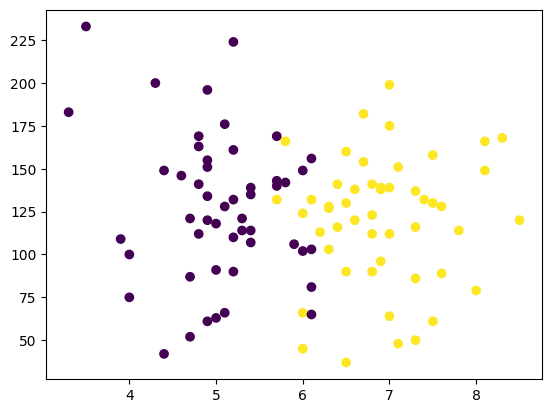

In [31]:
# 0. EDA (Exploratory Data Analysis)

import matplotlib.pyplot as plt

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [32]:
# 1. Extract input and output cols
X = df.iloc[:,0:2]  # Input features (cgpa and iq)  means all rows and first two columns
y = df.iloc[:,-1]   # Output variable (placement)   means all rows and last column

In [33]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [34]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [35]:

X.shape

(100, 2)

In [36]:
# 2. Train test split   (90% train and 10% test)
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1)

In [37]:
X_train

,cgpa,iq
52,7.0,175.0
28,5.2,90.0
29,7.0,112.0
19,5.2,132.0
90,7.3,86.0
...,...,...
93,6.8,112.0
79,6.5,90.0
0,6.8,123.0
99,6.2,113.0


In [38]:
y_train

52    1
28    0
29    1
19    0
90    1
     ..
93    1
79    1
0     1
99    1
49    0
Name: placement, Length: 90, dtype: int64

In [39]:
X_test

,cgpa,iq
35,6.8,90.0
92,5.2,110.0
17,3.3,183.0
85,5.8,166.0
56,6.1,65.0
65,8.1,166.0
4,5.8,142.0
83,7.5,130.0
88,4.4,149.0
48,6.6,138.0


In [40]:
y_test

35    1
92    0
17    0
85    1
56    0
65    1
4     0
83    1
88    0
48    1
Name: placement, dtype: int64

In [41]:
# 3. Scale the values                       (normalize or standardize the features ie. bween 0 and 1 or mean=0 and std=1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train

array([[ 0.9044462 ,  1.31083872],
       [-0.71456246, -0.80878001],
       [ 0.9044462 , -0.26017281],
       [-0.71456246,  0.23856101],
       [ 1.17428097, -0.90852677],
       [-1.79390157, -1.18283037],
       [ 0.27483172,  0.11387756],
       [-1.8838465 , -0.33498288],
       [ 0.09494187,  0.83704159],
       [ 1.6240056 , -0.21029943],
       [-1.25423202,  0.58767468],
       [-0.80450739,  1.33577541],
       [ 1.35417082,  0.88691497],
       [ 0.36477664,  0.46299123],
       [-0.26483784,  0.23856101],
       [ 1.44411575, -0.8337167 ],
       [ 2.07373023,  1.13628188],
       [ 0.09494187, -1.03321023],
       [ 1.80389545, -1.08308361],
       [-0.71456246,  0.96172505],
       [-0.80450739,  0.13881425],
       [-1.07434217,  1.16121858],
       [-0.53467261,  0.41311785],
       [ 0.00499694, -1.40726059],
       [ 0.09494187,  0.23856101],
       [-1.79390157, -0.5594131 ],
       [ 0.99439112,  0.71235814],
       [-0.89445232, -1.48207067],
       [ 0.72455635,

In [42]:
X_test = scaler.transform(X_test)   # We use transform here because we want to use the same scaler that we fitted on the training data to transform the test data
X_test

array([[ 0.72455635, -0.80878001],
       [-0.71456246, -0.31004619],
       [-2.42351605,  1.51033225],
       [-0.17489291,  1.0864085 ],
       [ 0.09494187, -1.43219728],
       [ 1.89384038,  1.0864085 ],
       [-0.17489291,  0.48792792],
       [ 1.35417082,  0.18868763],
       [-1.43412187,  0.66248476],
       [ 0.54466649,  0.38818116]])

In [43]:
# 4. Train the model                        (choose an algorithm and fit the model on the training data)
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
# 5. Evaluate the model/model selection    (evaluate the model on the test set and compare with other models to select the best one)

# clf.predict(X_test)   # This will give us the predicted output values for the test set

y_pred = clf.predict(X_test)

In [51]:
y_test      # Actual output values

35    1
92    0
17    0
85    1
56    0
65    1
4     0
83    1
88    0
48    1
Name: placement, dtype: int64

In [53]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)       # Accuracy is the ratio of correctly predicted observations to the total observations. It is a common metric for classification problems, but it can be misleading if the classes are imbalanced. In such cases, other metrics like precision, recall, and F1-score should be considered.


0.8

<Axes: >

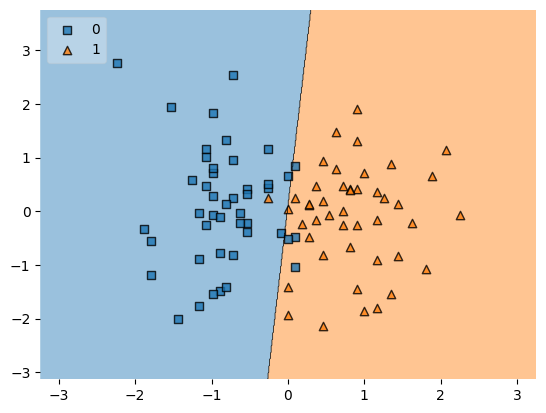

In [47]:
# plotting the decision boundary
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [54]:
# pkckle used to exprot the pkl trained model file for further use in deployment

import pickle
pickle.dump(clf,open('model.pkl','wb'))